# Figure 4(B) — Preferred-tier base pairs before/after PDB-REDO

Top-scoring pairs stay essentially unchanged after re-refinement.

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

_ROOT = Path.cwd().parent.parent
FIGURES = _ROOT / "figures"

def data_file(rel):
    return _ROOT / "data" / rel

def savefig(fig, name, dpi=150):
    FIGURES.mkdir(exist_ok=True)
    fig.savefig(FIGURES / name, dpi=dpi, bbox_inches="tight")
    return Path("figures") / name

In [2]:
HIGH_THRESH = 100


def load():
    """Return (df with delta = redo-orig, summary dict)."""
    data = json.load(open(data_file("validation/pdb_redo_pairs_comparison.json")))
    df = pd.DataFrame(data["pairs"])
    df["delta"] = df["redo_score"] - df["orig_score"]
    return df, data["summary"]

In [3]:
df, summary = load()

Excluded from view: 41 of 43,624 preferred-tier pairs (0.094%) with redo score < 75:
  redo= 49.7  8G9Z  E-A-5B/E-U-67A
  redo= 51.8  4PWD  E-C-711/F-DG-817
  redo= 53.5  2UUB  A-A-923/A-U-1393
  redo= 57.6  3CZ3  E-G-9/F-C-11
  redo= 58.4  7QTN  A-C-13/B-G-16
  redo= 59.2  1X9K  A-U-13/B-A-3
  redo= 61.5  1M5K  D-A-5/E-U-87
  redo= 61.6  4PWD  E-C-712/F-DG-816
  redo= 62.2  4PWD  E-U-724/F-DA-804
  redo= 62.3  3CZ3  G-C-7/H-G-13
  redo= 62.8  2E5L  A-U-677/A-G-713
  redo= 64.2  3SN2  B-U-5/B-A-27
  redo= 64.9  7A0S  X-G-849/X-U-954
  redo= 65.1  2UXC  A-G-78/A-C-91
  redo= 65.6  3CZ3  E-G-6/F-C-14
  redo= 66.3  6M0X  C-DT-8/D-DA-1
  redo= 67.1  2UUB  A-G-29/A-C-554
  redo= 68.2  7A0S  X-G-1668/X-C-1989
  redo= 69.0  4NIA  X-A-167/m-U-183
  redo= 69.4  1N32  A-G-376/A-U-387
  redo= 70.1  2O3Y  A-U-10/B-A-38
  redo= 71.0  1M5K  A-A-5/B-U-87
  redo= 71.1  2UUA  A-G-29/A-C-554
  redo= 71.4  7EAG  D-U-6/E-A-8
  redo= 72.1  5UD5  D-U-19/D-A-56
  redo= 72.1  7A0S  X-C-853/X-G-949
  redo= 72.

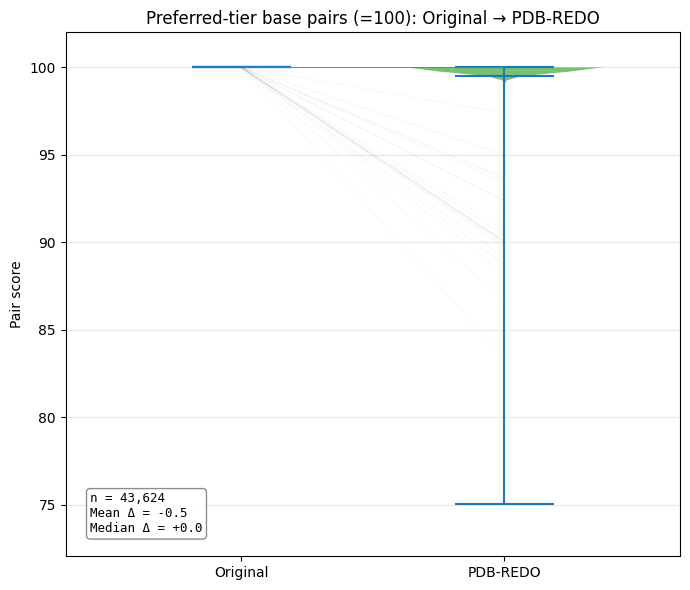

In [4]:
sub_all = df[df['orig_score'] >= HIGH_THRESH].copy()

# --- documented outlier exclusion (display only) ---------------------------
# A handful of preferred-tier pairs suffer large drops after re-refinement and
# stretch the y-axis, obscuring that the tier is otherwise unchanged. We omit
# pairs that fell below 75 (a >25-point drop) FROM THE PLOT ONLY. Reported
# statistics below still cover the full preferred-tier set, and the excluded
# pairs are listed here for the record.
CUT = 75
excluded = sub_all[sub_all['redo_score'] < CUT]
sub = sub_all[sub_all['redo_score'] >= CUT].copy()
print(f"Excluded from view: {len(excluded)} of {len(sub_all):,} preferred-tier pairs "
      f"({100*len(excluded)/len(sub_all):.3f}%) with redo score < {CUT}:")
for _, r in excluded.sort_values('redo_score').iterrows():
    print(f"  redo={r['redo_score']:5.1f}  {r['pdb_id']}  {r['res_id1']}/{r['res_id2']}")

fig, ax = plt.subplots(figsize=(7, 6))
positions = [1.0, 1.6]
parts = ax.violinplot([sub['orig_score'].values, sub['redo_score'].values],
                      positions=positions, widths=0.45,
                      showmeans=True, showmedians=True, showextrema=True)
for pc, c in zip(parts['bodies'], ['tab:blue', 'tab:green']):
    pc.set_facecolor(c); pc.set_alpha(0.65)
sample = sub.sample(min(300, len(sub)), random_state=42)
for _, row in sample.iterrows():
    ax.plot(positions, [row['orig_score'], row['redo_score']], color='gray', alpha=0.08, lw=0.5)

d_all = sub_all['delta']
ax.text(0.04, 0.04, f"n = {len(sub_all):,}\nMean \u0394 = {d_all.mean():+.1f}\nMedian \u0394 = {d_all.median():+.1f}",
        transform=ax.transAxes, ha='left', va='bottom', fontsize=9, family='monospace',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.9))

allv = pd.concat([sub['orig_score'], sub['redo_score']])
pad = max(3, (allv.max() - allv.min()) * 0.12)
ax.set_ylim(max(0, allv.min() - pad), min(102, allv.max() + pad))
ax.set_xticks(positions); ax.set_xticklabels(['Original', 'PDB-REDO']); ax.set_xlim(0.6, 2.0)
ax.set_ylabel('Pair score'); ax.set_title('Preferred-tier base pairs (=100): Original \u2192 PDB-REDO')
ax.grid(axis='y', alpha=0.3)
fig.tight_layout(); print('saved', savefig(fig, 'figure4_B_preferred_tier_before_after.png')); plt.show()